<a href="https://colab.research.google.com/github/dinathsv/E2340013_ML_Assigenment_01/blob/main/E2340013_ML_Assigenment_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Task 1: Data Preparation**

---

Imports & Load Data

In [ ]:
# Load the Breast Cancer Wisconsin Diagnostic Dataset from scikit-learn's built-in datasets
# (identical data to the UCI ML Repository version: 569 samples, 30 numeric features)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay)

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target # sklearn default: 0 = malignant, 1 = benign (will be flipped below)

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Fix label encoding to match assignment spec

In [ ]:
# sklearn's default target encoding is the opposite of what the assignment requires.
# Re-map so Malignant = 1 (cancerous) and Benign = 0 (non-cancerous), as specified.
df['target'] = df['target'].map({0: 1, 1: 0})
print(df['target'].value_counts())

target
0    357
1    212
Name: count, dtype: int64


Explore the dataset

Shape: (569, 31)

Data types:
 float64    30
int64       1
Name: count, dtype: int64

Missing values:
 0

Class distribution:
target
0    0.627417
1    0.372583
Name: proportion, dtype: float64


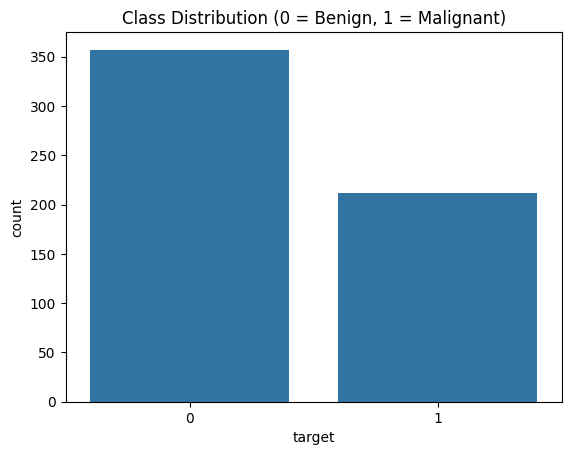

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [ ]:
# Inspect dataset shape, data types, missing values, and class balance
print("Shape:", df.shape)                          # rows x columns
print("\nData types:\n", df.dtypes.value_counts())  # confirm all features are numeric
print("\nMissing values:\n", df.isnull().sum().sum())
print("\nClass distribution:")
print(df['target'].value_counts(normalize=True))    # check for class imbalance

# Visualize class balance
sns.countplot(x='target', data=df)
plt.title("Class Distribution (0 = Benign, 1 = Malignant)")
plt.show()

# Summary statistics for all numerical features (mean, std, min, max, quartiles)
df.describe().T

Preprocessing

In [ ]:
# Confirm there are no missing values needing imputation
print("Missing values per column:\n", df.isnull().sum()[df.isnull().sum() > 0])

# Separate features (X) from the target label (y)
# No ID column to drop here, since the sklearn version doesn't include one
X = df.drop('target', axis=1)
y = df['target']

# 80-20 train-test split, stratified so both sets keep the same class ratio as the full dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features (mean=0, std=1) - fit scaler on training data only, then apply to both
# sets to avoid data leakage from the test set into training
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, "Test shape:", X_test_scaled.shape)

Missing values per column:
 Series([], dtype: int64)
Train shape: (455, 30) Test shape: (114, 30)


**Task 2: SVM Model Development**

---

Linear Kernel SVM

In [ ]:
# Train an SVM with a Linear kernel - assumes classes are linearly separable
# probability=True enables predict_proba, needed later for the ROC-AUC score
svm_linear = SVC(kernel='linear', probability=True, random_state=42)
svm_linear.fit(X_train_scaled, y_train)
y_pred_linear = svm_linear.predict(X_test_scaled)
y_prob_linear = svm_linear.predict_proba(X_test_scaled)[:, 1]  # probability of malignant (class 1)

RBF Kernel SVM

In [ ]:
# Train an SVM with an RBF (Gaussian) kernel — can capture non-linear decision boundaries
svm_rbf = SVC(kernel='rbf', probability=True, random_state=42)
svm_rbf.fit(X_train_scaled, y_train)
y_pred_rbf = svm_rbf.predict(X_test_scaled)
y_prob_rbf = svm_rbf.predict_proba(X_test_scaled)[:, 1]

Hyperparameter tuning with GridSearchCV

In [ ]:
# Tune the RBF model's C (regularization strength) and gamma (kernel coefficient)
# using 5-fold cross-validation, optimizing for F1-score
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.001],
}
grid_rbf = GridSearchCV(SVC(kernel='rbf', probability=True, random_state=42),
                         param_grid, cv=5, scoring='f1')
grid_rbf.fit(X_train_scaled, y_train)
print("Best RBF params:", grid_rbf.best_params_)

svm_rbf_tuned = grid_rbf.best_estimator_
y_pred_rbf_tuned = svm_rbf_tuned.predict(X_test_scaled)
y_prob_rbf_tuned = svm_rbf_tuned.predict_proba(X_test_scaled)[:, 1]

Best RBF params: {'C': 1, 'gamma': 'scale'}


**Task 3: Model Evaluation**

---

Comparison table

In [ ]:
# Compute all five required evaluation metrics for a given set of predictions
def evaluate(y_true, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }

# Evaluate both models on the same held-out test set for a fair comparison
results_linear = evaluate(y_test, y_pred_linear, y_prob_linear)
results_rbf = evaluate(y_test, y_pred_rbf, y_prob_rbf)

comparison_df = pd.DataFrame({'Linear SVM': results_linear, 'RBF SVM': results_rbf}).round(4)
print(comparison_df)

           Linear SVM  RBF SVM
Accuracy       0.9649   0.9737
Precision      1.0000   1.0000
Recall         0.9048   0.9286
F1-Score       0.9500   0.9630
ROC-AUC        0.9914   0.9947


**Task 4: Confusion Matrix & ROC Analysis**

---

Pick the best model, then confusion matrix

Best performing model: RBF SVM
True Negatives: 72, False Positives: 0, False Negatives: 3, True Positives: 39


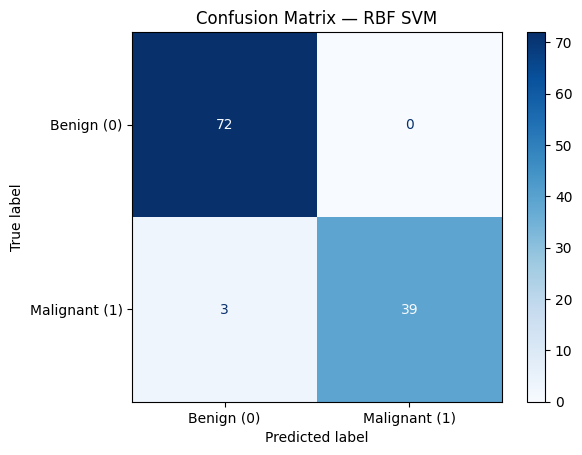

In [ ]:
# Select the better-performing model (by F1-score) for detailed confusion matrix and ROC analysis
best_model_name = 'RBF SVM' if results_rbf['F1-Score'] > results_linear['F1-Score'] else 'Linear SVM'
best_pred = y_pred_rbf if best_model_name == 'RBF SVM' else y_pred_linear
best_prob = y_prob_rbf if best_model_name == 'RBF SVM' else y_prob_linear

print("Best performing model:", best_model_name)

# Build confusion matrix and extract TN, FP, FN, TP counts
cm = confusion_matrix(y_test, best_pred)
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives: {tn}, False Positives: {fp}, False Negatives: {fn}, True Positives: {tp}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign (0)', 'Malignant (1)'])
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()

ROC Curve

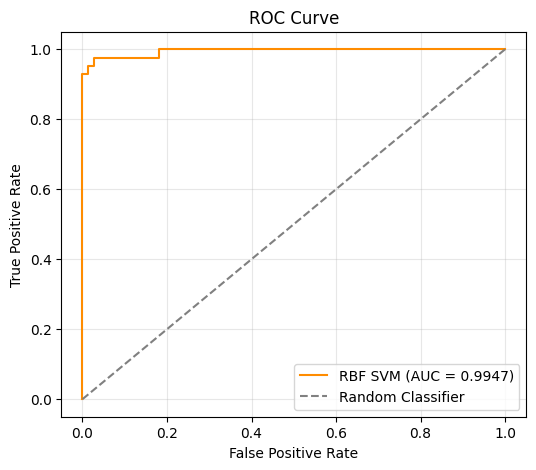

AUC Score: 0.9947


In [ ]:
# Compute the ROC curve (True Positive Rate vs False Positive Rate across thresholds) and AUC
fpr, tpr, thresholds = roc_curve(y_test, best_prob)
auc_score = roc_auc_score(y_test, best_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {auc_score:.4f})", color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')  # baseline reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f"AUC Score: {auc_score:.4f}")